# Normalisations and the structure of a covariance

Five experiments measure the same curve, and each multiplies its data by a
normalisation it does not know exactly — a flux, an efficiency, a target
thickness.  Each quotes a systematic uncertainty for that factor.  Some of those
quotes are good; at least one, as usually happens, is not.

What we do with those quoted numbers is the whole question here.  We will try
six things — three defensible, three not — and see which recover the curve.
Then we take a covariance apart and look at the pattern each kind of term writes
into it.

Recipes: 3, 4, 6, 27

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from numpy.polynomial import polynomial as P
from scipy import stats
from scipy.optimize import minimize_scalar
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

import rxmc as rx
from rxmc import terms as T
from rxmc import transforms as tf

plotstyle.use()

## Five experiments, and what they told us

Each entry of `settings` is one experiment: where it measured, how many points,
its statistical noise, the systematic uncertainty it *reported* for its
normalisation, and — because this is synthetic data — the normalisation it
actually had.

We do **not** draw the true renormalisation from the reported systematic.  We
choose it by hand, because that is what real data are like:

- `exp 0` is **absolutely normalised**: it quotes no normalisation uncertainty
  and has none.  Some experiment has to play this role, and we will see why in
  a moment.
- `exp 1`, `exp 2`, `exp 4` are honest: their renormalisations sit comfortably
  inside what they quoted.  `exp 4` was simply very conservative, quoting 25 %
  when it was within 2 %.
- `exp 3` quoted 3 % and is in fact 15 % high — five standard deviations out.
  It is also the *only* experiment covering the high-$x$ region, which is what
  makes it dangerous.

Comment a line out to drop that experiment from everything below.

In [2]:
settings = {
    "exp 0": {
        "domain": (0.20, 0.60),
        "n": 35,
        "noise": 0.010,
        "sys": 0.00,
        "rho": 1.00,
    },
    "exp 1": {
        "domain": (0.30, 0.70),
        "n": 25,
        "noise": 0.012,
        "sys": 0.08,
        "rho": 0.94,
    },
    "exp 2": {
        "domain": (0.25, 0.65),
        "n": 25,
        "noise": 0.010,
        "sys": 0.12,
        "rho": 1.10,
    },
    "exp 3": {
        "domain": (0.90, 1.40),
        "n": 40,
        "noise": 0.010,
        "sys": 0.03,
        "rho": 1.15,
    },
    "exp 4": {
        "domain": (0.35, 0.75),
        "n": 25,
        "noise": 0.015,
        "sys": 0.25,
        "rho": 1.02,
    },
}
for label, s in settings.items():
    off = abs(s["rho"] - 1)
    sigmas = "absolute" if s["sys"] == 0 else f"{off / s['sys']:.1f} sigma"
    print(f"{label}: quoted {s['sys']:.0%}, actually {s['rho'] - 1:+.0%}  ({sigmas})")

exp 0: quoted 0%, actually +0%  (absolute)
exp 1: quoted 8%, actually -6%  (0.8 sigma)
exp 2: quoted 12%, actually +10%  (0.8 sigma)
exp 3: quoted 3%, actually +15%  (5.0 sigma)
exp 4: quoted 25%, actually +2%  (0.1 sigma)


In [3]:
rng = np.random.default_rng(42)
a_true = np.array([0.0, 1.0, -0.3, -0.6])  # a_0 is zero, and stays zero


def truth(x):
    return P.polyval(np.asarray(x, dtype=float), a_true)


datasets = {}
for label, s in settings.items():
    x = np.sort(rng.uniform(*s["domain"], s["n"]))
    y = rng.normal(truth(x) * s["rho"], s["noise"])
    datasets[label] = rx.Dataset(
        x, y, np.full(s["n"], s["noise"]), norm_err=s["sys"], label=label
    )
x_fine = np.linspace(0.18, 1.42, 140)
x_high = np.linspace(1.0, 1.40, 30)  # the region only exp 3 covers

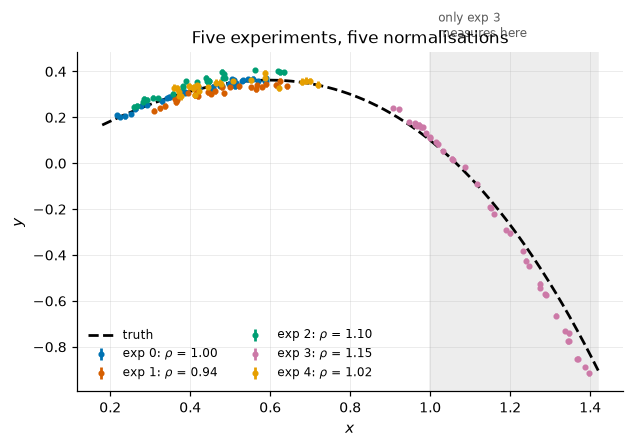

In [4]:
fig, ax = plt.subplots()
ax.plot(x_fine, truth(x_fine), "--", color="k", label="truth")
for (label, d), colour in zip(datasets.items(), plotstyle.COLOURS):
    ax.errorbar(
        d.x,
        d.y,
        d.y_err,
        fmt="o",
        ms=3,
        color=colour,
        label=rf"{label}: $\rho$ = {settings[label]['rho']:.2f}",
    )
ax.axvspan(1.0, 1.42, color="0.93", zorder=0)
ax.text(1.02, 0.55, "only exp 3\nmeasures here", fontsize=8, color="0.35")
ax.set(xlabel="$x$", ylabel="$y$", title="Five experiments, five normalisations")
ax.legend(fontsize=8, ncol=2)
plt.show()

## The model, and why one experiment must be absolute

The truth is a cubic with $a_0 = 0$, and we hold $a_0$ at zero rather than
inferring it: an additive constant and a multiplicative normalisation are nearly
the same thing over a short range, so leaving both free would confound them.

That is not enough on its own.  If *every* experiment may renormalise itself,
then shrinking all the $\rho_i$ by 10 % and raising the curve by 10 % fits
exactly as well — the overall scale is unidentifiable, and the fit wanders.
Something has to fix it, and the honest way is an experiment that measured the
absolute scale: `exp 0` here.  The rest are then normalised relative to it.

In [5]:
coeffs = [
    rx.Parameter(f"a{k}", prior=stats.norm(0.0, 1.5), latex=f"a_{k}") for k in (1, 2, 3)
]
cubic = rx.Model(
    lambda x, *a: P.polyval(np.asarray(x, dtype=float), (0.0,) + a), coeffs
)
comps = {label: rx.Comparison(d, cubic) for label, d in datasets.items()}
free = [label for label, s in settings.items() if s["sys"] > 0]
print("normalisation free for:", free)

normalisation free for: ['exp 1', 'exp 2', 'exp 3', 'exp 4']


In [6]:
def fit(problem, seed, n_walkers=32, n_steps=2000):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


def curves(problem, samples, grid, n=200):
    """The bare cubic's curves on a grid: the physics, not the renormalised data."""
    return rx.predictive.grid_draws(
        problem,
        cubic.bind(grid),
        grid,
        samples[-n:],
        model_only=True,
        return_draws=True,
    )

## Three defensible things to do

**1. Believe the quoted systematic (recipe 3).**  Each dataset's `norm_err`
becomes a rank-one mode built from the prediction; `comp.reported_terms()`
spells exactly that.  This is the standard thing to do.

**2. Infer the normalisation (recipe 6).**  Give each dataset a latent scale
$\rho_i$ on the *model*, with the quoted systematic as its prior width, and let
the data move it.

**3. Infer the systematic magnitude (recipe 4).**  Keep the mode in the
covariance, but treat its size $\eta_i$ as a nuisance parameter per dataset
instead of a number we were handed.

All three say "there is a normalisation here".  They differ in how much they
trust the quote.

In [7]:
rhos = {
    label: rx.Parameter(
        f"log_rho_{i}",
        prior=stats.norm(0.0, np.log1p(settings[label]["sys"])),
        latex=rf"\log\rho_{i}",
    )
    for i, label in enumerate(free)
}
etas = {
    label: rx.Parameter(
        f"log_eta_{i}",
        prior=stats.norm(np.log(settings[label]["sys"]), 0.7),
        latex=rf"\log\eta_{i}",
    )
    for i, label in enumerate(free)
}
comps_scaled = [
    (
        rx.Comparison(d, cubic | tf.scale(rhos[label]))
        if label in free
        else rx.Comparison(d, cubic)
    )
    for label, d in datasets.items()
]

In [8]:
correct = {
    "quoted systematics": rx.Problem(
        [
            rx.Constraint(
                list(comps.values()),
                terms=[t for label in free for t in comps[label].reported_terms()],
            )
        ]
    ),
    "inferred normalisations": rx.Problem([rx.Constraint(comps_scaled)]),
    "inferred systematics": rx.Problem(
        [
            rx.Constraint(
                list(comps.values()),
                terms=[
                    T.normalization(parameter=etas[label], on=comps[label])
                    for label in free
                ],
            )
        ]
    ),
}
for name, p in correct.items():
    print(f"{name:24s} {p.ndim} columns")

quoted systematics       3 columns
inferred normalisations  7 columns
inferred systematics     7 columns


## Three things not to do

**4. Peelle's Pertinent Puzzle (recipe 27).**  Build the same mode from the
*measured* values instead of the prediction, so the fluctuations feed back into
the covariance.

**5. Ignore the systematics.**  Quoted statistics only, as if every
normalisation were exact.

**6. Infer statistical uncertainties instead.**  Notice that the datasets
disagree, blame the noise, and let a free diagonal absorb it.  It looks like
inference, and it is the wrong model: a normalisation moves a whole dataset
together, and no diagonal can say that.

In [9]:
log_eps = rx.Parameter(
    "log_eps", prior=stats.norm(np.log(0.02), 1.0), latex=r"\log\epsilon"
)
wrong = {
    "PPP: mode from the data": rx.Problem(
        [
            rx.Constraint(
                list(comps.values()),
                terms=[
                    rx.Term(
                        settings[label]["sys"] * datasets[label].y,
                        kind="mode",
                        on=comps[label],
                    )
                    for label in free
                ],
            )
        ]
    ),
    "systematics ignored": rx.Problem([rx.Constraint(list(comps.values()))]),
    "statistics inferred": rx.Problem(
        [
            rx.Constraint(
                list(comps.values()),
                terms=[T.noise_fraction(log_eps)],
                statistical=False,
            )
        ]
    ),
}
for name, p in wrong.items():
    print(f"{name:24s} {p.ndim} columns")

PPP: mode from the data  3 columns
systematics ignored      3 columns
statistics inferred      4 columns


In [10]:
problems = {**correct, **wrong}
samples = {name: fit(p, seed=i) for i, (name, p) in enumerate(problems.items())}
style = dict(
    zip(
        problems,
        zip(
            [plotstyle.COLOURS[i] for i in (0, 2, 5, 1, 3, 6)],
            plotstyle.HATCHES + plotstyle.HATCHES,
        ),
    )
)

In [11]:
def report(names):
    for name in names:
        p, s = problems[name], samples[name]
        cols = p.columns(cubic.params)
        pulls = [
            (s[:, c].mean() - a_true[k + 1]) / s[:, c].std() for k, c in enumerate(cols)
        ]
        mean_high = curves(p, s, x_high).mean(axis=0)
        rms = np.sqrt(np.mean((mean_high - truth(x_high)) ** 2))
        print(
            f"{name:24s} "
            + "  ".join(
                f"a{k + 1}={s[:, c].mean():+.2f}+/-{s[:, c].std():.2f}"
                for k, c in enumerate(cols)
            )
            + f"   max|pull| = {max(abs(z) for z in pulls):4.1f}"
            + f"   RMS over exp 3's range = {rms:.3f}"
        )


print("the three defensible ones")
report(correct)
print("\nthe three wrong ones")
report(wrong)

the three defensible ones
quoted systematics       a1=+1.56+/-0.81  a2=-2.52+/-3.21  a3=+1.50+/-3.00   max|pull| =  0.7   RMS over exp 3's range = 1.269
inferred normalisations  a1=+0.98+/-0.02  a2=-0.21+/-0.05  a3=-0.67+/-0.03   max|pull| =  2.2   RMS over exp 3's range = 0.015
inferred systematics     a1=+1.00+/-0.02  a2=-0.29+/-0.05  a3=-0.61+/-0.03   max|pull| =  0.3   RMS over exp 3's range = 0.004

the three wrong ones
PPP: mode from the data  a1=+0.98+/-0.02  a2=-0.24+/-0.05  a3=-0.64+/-0.03   max|pull| =  1.2   RMS over exp 3's range = 0.009
systematics ignored      a1=+0.91+/-0.01  a2=+0.03+/-0.02  a3=-0.84+/-0.01   max|pull| = 18.1   RMS over exp 3's range = 0.061
statistics inferred      a1=+0.87+/-0.55  a2=-0.29+/-0.88  a3=-0.69+/-0.44   max|pull| =  0.2   RMS over exp 3's range = 0.281


### What that table says

The first row is the one to look at.  `quoted systematics` is the standard thing
to do, and here it fails.  `exp 3` quoted 3 %, so the fit is obliged to believe
its scale to within 3 % — and since `exp 3` is the only experiment in the
high-$x$ region, the cubic has to bend to follow data that are 15 % high.  It
cannot do that and still fit the others, so it gives way in the only direction
left to it: the coefficients acquire enormous uncertainties
($a_2 = -2.52 \pm 3.21$) and the predicted curve is *still* wrong, with an RMS
error of 1.27 over `exp 3`'s range against 0.004 for the best case.

Notice that this case has the **smallest** `max|pull|` of the three, 0.7.  The
pulls look innocent precisely because the error bars exploded.  Had we judged
these fits by parameter pulls alone, we would have called the broken one fine —
which is the argument for looking at the prediction as well.

Both cases that infer the normalisation recover the curve, which is what we
hoped for: RMS 0.015 for the sampled scale $\rho_i$, and 0.004 for the sampled
magnitude $\eta_i$.  Inferring $\eta$ wins here because it keeps the quoted
values as a starting point and only widens the ones the data cannot live with.

Among the three we called wrong, ignoring the systematics is the classic:
$a_2 = +0.03 \pm 0.02$, eighteen standard deviations from the truth, precise and
wrong.  Inferring the *statistical* errors instead technically covers the truth,
but only by inflating everything until the answer says nothing
($a_2 = -0.29 \pm 0.88$).  And the Peelle mode is, in this configuration, nearly
harmless — RMS 0.009.  That deserves an explanation rather than a shrug, and it
gets one two sections below.

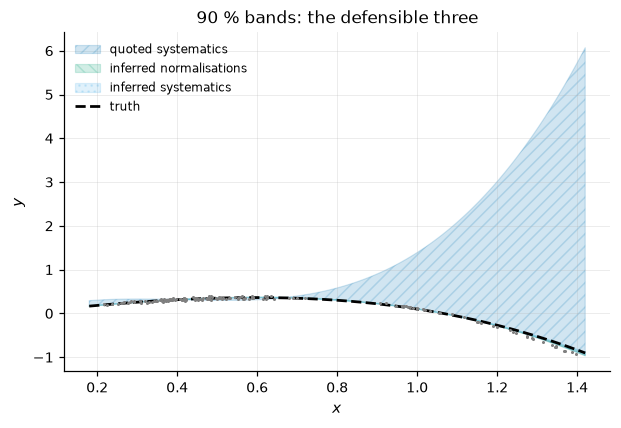

In [12]:
fig, ax = plt.subplots()
for name in correct:
    colour, hatch = style[name]
    lo, hi = np.percentile(
        curves(problems[name], samples[name], x_fine), [5, 95], axis=0
    )
    plotstyle.band(ax, x_fine, lo, hi, color=colour, hatch=hatch, label=name)
ax.plot(x_fine, truth(x_fine), "--", color="k", label="truth")
for d, colour in zip(datasets.values(), plotstyle.COLOURS):
    ax.plot(d.x, d.y, ".", ms=2, color="0.5")
ax.set(xlabel="$x$", ylabel="$y$", title="90 % bands: the defensible three")
ax.legend(fontsize=8)
plt.show()

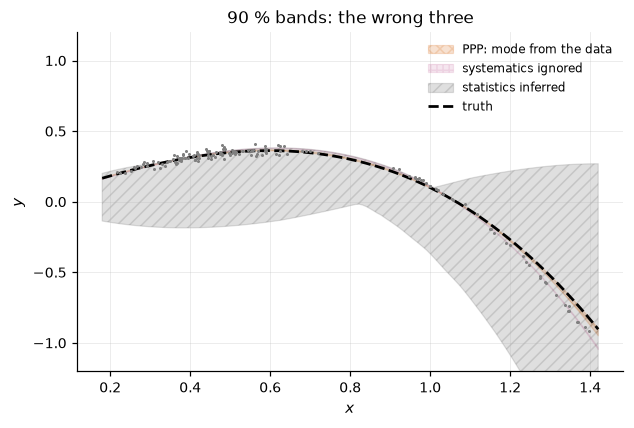

In [13]:
fig, ax = plt.subplots()
for name in wrong:
    colour, hatch = style[name]
    lo, hi = np.percentile(
        curves(problems[name], samples[name], x_fine), [5, 95], axis=0
    )
    plotstyle.band(ax, x_fine, lo, hi, color=colour, hatch=hatch, label=name)
ax.plot(x_fine, truth(x_fine), "--", color="k", label="truth")
for d, colour in zip(datasets.values(), plotstyle.COLOURS):
    ax.plot(d.x, d.y, ".", ms=2, color="0.5")
ax.set(
    xlabel="$x$",
    ylabel="$y$",
    ylim=(-1.2, 1.2),
    title="90 % bands: the wrong three",
)
ax.legend(fontsize=8)
plt.show()

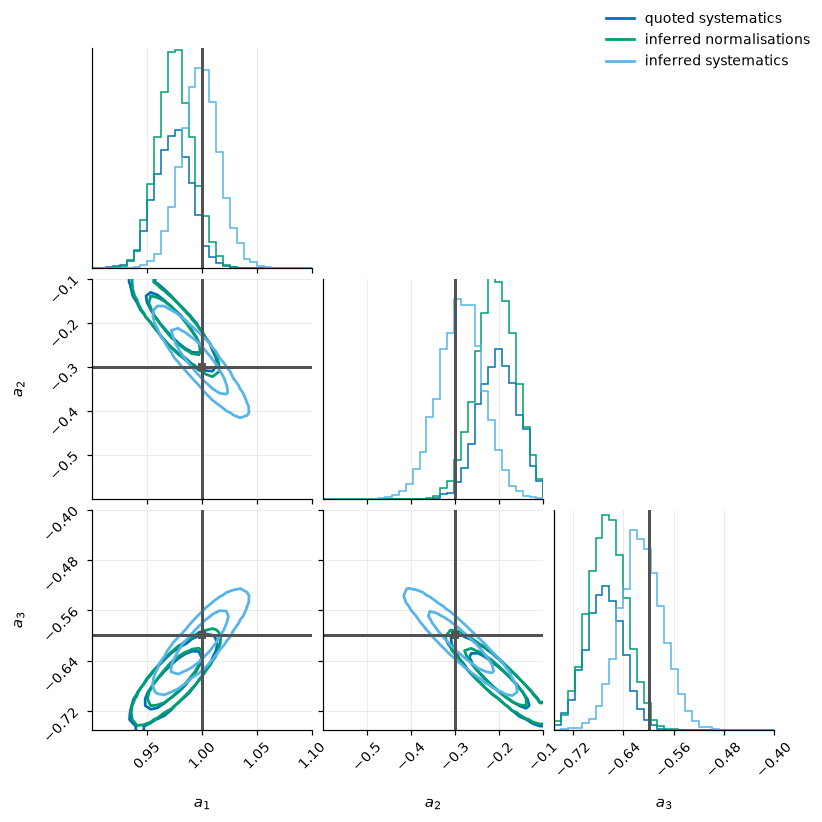

In [14]:
fig = None
for name in correct:
    colour, _ = style[name]
    p = problems[name]
    fig = corner.corner(
        samples[name][:, p.columns(cubic.params)],
        fig=fig,
        labels=[f"${c.latex}$" for c in cubic.params],
        truths=a_true[1:],
        range=[(0.9, 1.1), (-0.6, -0.1), (-0.75, -0.4)],
        **plotstyle.corner_kwargs(
            color=colour,
            fill_contours=False,
            plot_density=False,
            show_titles=False,
            levels=(0.68, 0.95),
        ),
    )
fig.legend(
    handles=[plt.Line2D([], [], color=style[n][0], label=n) for n in correct],
    loc="upper right",
    fontsize=9,
)
plt.show()

### What the normalisations came out as

Two of the defensible cases infer a number per dataset, and we can hold them up
against the renormalisations we planted.  Case 2 infers the scale $\rho_i$
directly.  Case 3 infers the *width* $\eta_i$ of the mode, so it does not say
which way a dataset moved, only how far it is prepared to let it move.

Watch `exp 3`, which quoted 3 % and needed 15 %, and `exp 4`, which quoted 25 %
and needed none of it.

In [15]:
p_rho, s_rho = correct["inferred normalisations"], samples["inferred normalisations"]
p_eta, s_eta = correct["inferred systematics"], samples["inferred systematics"]
header = f"{'dataset':8s} {'quoted':>7s} {'true rho':>9s} {'inferred rho':>16s} {'inferred eta':>16s}"
print(header)
for label in free:
    rho_draws = np.exp(s_rho[:, p_rho.columns(rhos[label])])
    eta_draws = np.exp(s_eta[:, p_eta.columns(etas[label])])
    print(
        f"{label:8s} {settings[label]['sys']:7.0%} {settings[label]['rho']:9.2f} "
        f"{rho_draws.mean():10.2f} +/- {rho_draws.std():.2f} "
        f"{eta_draws.mean():10.0%} +/- {eta_draws.std():.0%}"
    )

dataset   quoted  true rho     inferred rho     inferred eta
exp 1         8%      0.94       0.93 +/- 0.01         9% +/- 6%
exp 2        12%      1.10       1.09 +/- 0.01        14% +/- 9%
exp 3         3%      1.15       1.11 +/- 0.02        10% +/- 4%
exp 4        25%      1.02       1.01 +/- 0.01        21% +/- 16%


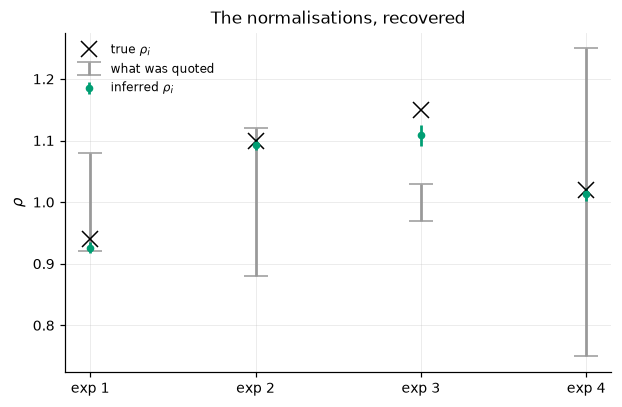

In [16]:
fig, ax = plt.subplots()
positions = np.arange(len(free))
rho_mean = [np.exp(s_rho[:, p_rho.columns(rhos[label])]).mean() for label in free]
rho_std = [np.exp(s_rho[:, p_rho.columns(rhos[label])]).std() for label in free]
ax.errorbar(
    positions,
    np.ones(len(free)),
    [settings[label]["sys"] for label in free],
    fmt="none",
    ecolor="0.6",
    capsize=8,
    label="what was quoted",
)
ax.errorbar(
    positions,
    rho_mean,
    rho_std,
    fmt="o",
    color=plotstyle.COLOURS[2],
    label=r"inferred $\rho_i$",
)
ax.plot(
    positions,
    [settings[label]["rho"] for label in free],
    "x",
    ms=11,
    color="k",
    label=r"true $\rho_i$",
)
ax.set(
    xticks=positions,
    xticklabels=free,
    ylabel=r"$\rho$",
    title="The normalisations, recovered",
)
ax.legend(fontsize=8)
plt.show()

## Where the Peelle mode actually bites

In the comparison above, building the mode from the data barely moved the
answer.  That is worth understanding rather than glossing over: with an
absolutely normalised experiment holding the scale and four others overlapping,
there is very little room for the covariance to pull the fit down.

Peelle's Pertinent Puzzle shows itself in the case it was discovered in —
fitting a *constant* to data that share one normalisation.  Two points, 1.5 and
1.0, each with a 10 % statistical error and a common 20 % normalisation
uncertainty.  Build the mode from the prediction and the fit lands between the
points; build it from the data and it lands **below both of them**, at exactly
the value [D'Agostini
(1994)](https://doi.org/10.1016/0168-9002(94)90719-6) derived:

$$t = \frac{\bar y}{1 + (s/\sigma)^2 \sum_i (y_i - \bar y)^2}.$$

In [17]:
y_pair = np.array([1.5, 1.0])
sigma_pair, s_pair = 0.1, 0.2
d_pair = rx.Dataset(
    np.array([0.0, 1.0]), y_pair, np.full(2, sigma_pair), norm_err=s_pair, label="pair"
)
t = rx.Parameter("t", prior=stats.uniform(0.0, 5.0), latex="t")
const = rx.Model(lambda x, t: np.full(np.size(x), t), [t])
comp_pair = rx.Comparison(d_pair, const)

panel = {
    "mode from the prediction": rx.Constraint(
        [comp_pair], terms=[T.normalization(magnitude=s_pair)]
    ),
    "mode from the data (PPP)": rx.Constraint(
        [comp_pair], terms=[rx.Term(s_pair * d_pair.y, kind="mode", on=comp_pair)]
    ),
    "no normalisation at all": rx.Constraint([comp_pair]),
}
for name, c in panel.items():
    p = rx.Problem([c])
    best = minimize_scalar(
        lambda v: -p.log_posterior(np.array([v])), bounds=(0.1, 4.0), method="bounded"
    )
    print(f"{name:26s} MAP t = {best.x:.4f}")
y_bar = y_pair.mean()
closed = y_bar / (1 + (s_pair / sigma_pair) ** 2 * np.sum((y_pair - y_bar) ** 2))
print(f"\nthe data are {y_pair}, mean {y_bar:.3f}")
print(f"D'Agostini's closed form for the data-built mode: {closed:.4f}")

mode from the prediction   MAP t = 1.2035
mode from the data (PPP)   MAP t = 0.8333
no normalisation at all    MAP t = 1.2500

the data are [1.5 1. ], mean 1.250
D'Agostini's closed form for the data-built mode: 0.8333


## A gallery of covariance structures

Every term writes a pattern into $\Sigma$, and `constraint.matrix(theta)` hands
us the assembled covariance at any parameter values, so we can simply look.

In [18]:
def correlation(S):
    d = np.sqrt(np.diag(S))
    return S / np.outer(d, d)


def show(ax, S, title, dividers=()):
    im = ax.imshow(correlation(S), cmap="RdBu_r", vmin=-1, vmax=1)
    for k in dividers:
        ax.axhline(k - 0.5, color="k", lw=0.5)
        ax.axvline(k - 0.5, color="k", lw=0.5)
    ax.set(title=title, xticks=[], yticks=[])
    ax.grid(False)
    return im


first = comps["exp 0"]
theta_map = np.median(samples["quoted systematics"], axis=0)[: len(cubic.params)]

### 1. A systematic correlated across $x$: flat mode versus smooth kernel

A normalisation is a rank-one mode: every pair of points is correlated by the
same fraction, however far apart they are.  A Gaussian-process kernel instead
correlates neighbours in $x$ and forgets across the range.  Both are one term.

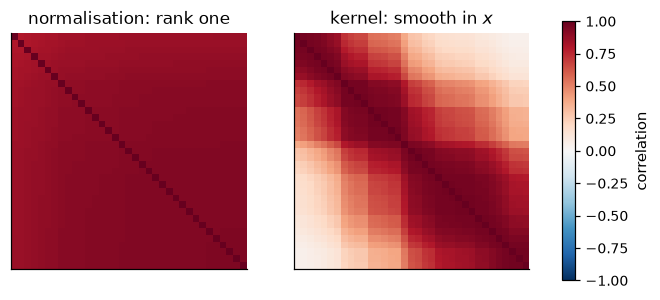

In [19]:
p_flat = rx.Problem([rx.Constraint([first], terms=[T.normalization(magnitude=0.1)])])
p_kernel = rx.Problem(
    [
        rx.Constraint(
            [first],
            terms=[T.kernel(ConstantKernel(0.05**2, "fixed") * RBF(0.15, "fixed"))],
        )
    ]
)
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6))
show(axes[0], p_flat.constraints[0].matrix(theta_map), "normalisation: rank one")
im = show(axes[1], p_kernel.constraints[0].matrix(theta_map), "kernel: smooth in $x$")
fig.colorbar(im, ax=axes, shrink=0.85, label="correlation")
plt.show()

### 2. Correlated statistical errors: bring the matrix, do not diagonalise it

If an experiment reports a full statistical covariance, we pass it as a fixed
`Term`.  Treating correlated noise as independent over-counts the information,
and the naive posterior comes out tighter than the correct one — tighter and
wrong, which is the theme of this notebook.

In [20]:
xs = np.linspace(0.0, 4.0, 20)
C = 0.15**2 * np.exp(-np.abs(xs[:, None] - xs[None, :]) / 1.2)
a_line = np.array([1.0, 0.8])
y_corr = a_line[0] + a_line[1] * xs + rng.multivariate_normal(np.zeros(20), C)
d_corr = rx.Dataset(xs, y_corr, np.sqrt(np.diag(C)), label="correlated noise")
m_ = rx.Parameter("m", prior=stats.norm(0, 5), latex="m")
b_ = rx.Parameter("b", prior=stats.norm(0, 5), latex="b")
line = rx.Model(lambda x, m, b: b + m * x, [m_, b_])
c_full = rx.Constraint(
    [rx.Comparison(d_corr, line)], terms=[rx.Term(C, kind="matrix")], statistical=False
)
c_diag = rx.Constraint([rx.Comparison(d_corr, line)])
s_full = fit(rx.Problem([c_full]), seed=11)
s_diag = fit(rx.Problem([c_diag]), seed=12)
print(
    f"diagonal only: m = {s_diag[:, 0].mean():.3f} +/- {s_diag[:, 0].std():.3f}   "
    f"full matrix: m = {s_full[:, 0].mean():.3f} +/- {s_full[:, 0].std():.3f}"
)

diagonal only: m = 0.829 +/- 0.027   full matrix: m = 0.834 +/- 0.050


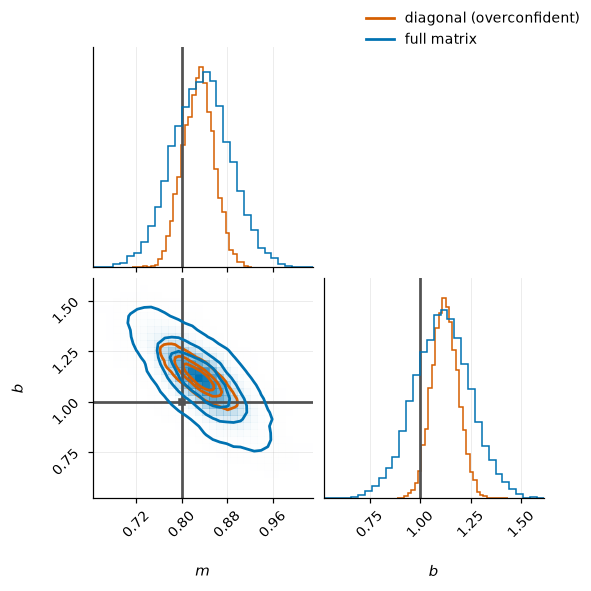

In [21]:
fig = corner.corner(
    s_diag,
    labels=["$m$", "$b$"],
    truths=[0.8, 1.0],
    **plotstyle.corner_kwargs(
        color=plotstyle.COLOURS[1], fill_contours=False, show_titles=False
    ),
)
corner.corner(
    s_full,
    fig=fig,
    **plotstyle.corner_kwargs(
        color=plotstyle.COLOURS[0], fill_contours=False, show_titles=False
    ),
)
fig.legend(
    handles=[
        plt.Line2D(
            [], [], color=plotstyle.COLOURS[1], label="diagonal (overconfident)"
        ),
        plt.Line2D([], [], color=plotstyle.COLOURS[0], label="full matrix"),
    ],
    loc="upper right",
)
plt.show()

### 3. Unknown or misreported magnitudes

A `model_error` term scales with the prediction, and its fraction sets how far
the total error exceeds what was reported.

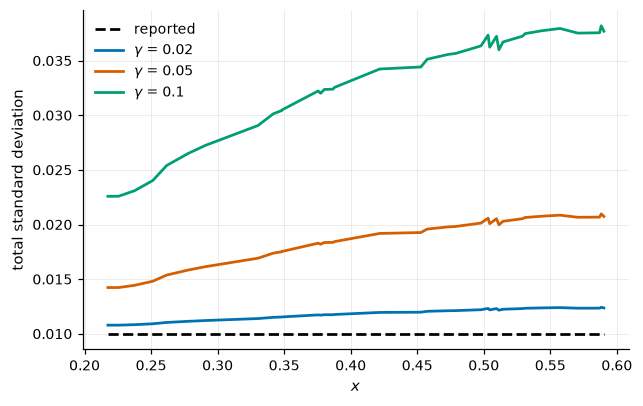

In [22]:
gamma = rx.Parameter(
    "log_gamma", prior=stats.norm(np.log(0.1), 0.5), latex=r"\log\gamma"
)
d0 = datasets["exp 0"]
fig, ax = plt.subplots()
ax.plot(d0.x, d0.y_err, "--", color="k", label="reported")
for g, colour in zip((0.02, 0.05, 0.10), plotstyle.COLOURS):
    p = rx.Problem(
        [rx.Constraint([first], terms=[T.model_error(gamma, averaging=True)])]
    )
    total = np.sqrt(np.diag(p.constraints[0].matrix(np.append(theta_map, np.log(g)))))
    ax.plot(d0.x, total, color=colour, label=rf"$\gamma$ = {g}")
ax.set(xlabel="$x$", ylabel="total standard deviation")
ax.legend()
plt.show()

### 4. A systematic shared across datasets

The same normalisation term `on` two comparisons couples their blocks; one term
per comparison leaves the covariance block diagonal.  Which is right depends on
whether the two experiments really shared a calibration — the subject of
`sharing_error_models`.

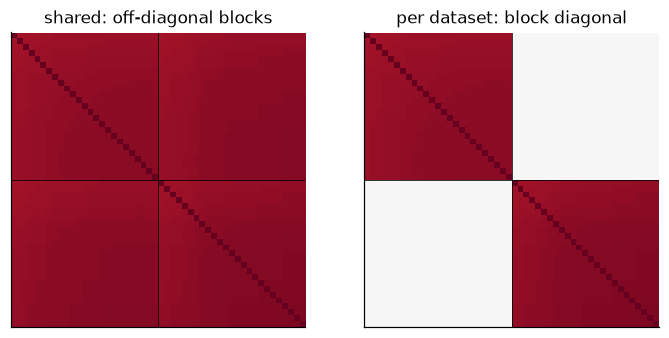

In [23]:
two = [comps["exp 1"], comps["exp 2"]]
c_shared = rx.Constraint(two, terms=[T.normalization(magnitude=0.1, on=two)])
c_each = rx.Constraint(two, terms=[T.normalization(magnitude=0.1, on=c) for c in two])
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6))
for ax, c, title in zip(
    axes,
    (c_shared, c_each),
    ("shared: off-diagonal blocks", "per dataset: block diagonal"),
):
    show(
        ax,
        rx.Problem([c]).constraints[0].matrix(theta_map),
        title,
        dividers=(datasets["exp 1"].n,),
    )
plt.show()

## Summary

| case | term | structure of $\Sigma$ |
|---|---|---|
| normalisation inferred | `model \| tf.scale(rho)` | none: the mean moves |
| quoted normalisation | `T.normalization(magnitude=)` | rank one, from the prediction |
| inferred systematic magnitude | `T.normalization(parameter=eta, on=comp)` | rank one, sampled size |
| smooth systematic in $x$ | `T.kernel(...)` | dense, decaying with distance |
| reported correlated statistics | `rx.Term(C, kind="matrix")` | whatever was reported |
| unknown model error | `T.model_error(gamma)` | sampled diagonal |
| shared across datasets | one term `on=[c1, c2]` | off-diagonal blocks |

Declaring the uncertainty *is* the modelling choice, and the inference machinery
does not change.  Whatever we declare, the mode multiplies the **prediction**,
never the data (recipe 27).